# Perturbation of Neoclassical Model

Pablo Winant

Our goal here is to compute a linear approximation of solution to the
neoclassical model, c# execute: \# freeze: true  
\# execute: \# enabled: falselose ot the steady-state.

1.  **Warm-up: install the `ForwardDiff` library. Use it to
    differentiate the function below. Check the jacobian function.**

Note: the signature of function `f` needs to be fixed first to allow for
dual numbers as arguments.

In [1]:
# function f(x::Vector{T}) where T <: Number
function f(x)
    a = x[1]
    b = x[2]
    x1 = a+b
    x2 = a*exp(b)
    return [x1,x2]
end

f (generic function with 1 method)

In [2]:
f([0.1, 0.2])

2-element Vector{Float64}:
 0.30000000000000004
 0.122140275816017

In [3]:
import ForwardDiff: jacobian
jacobian(f, [0.1, 0.2])

2×2 Matrix{Float64}:
 1.0     1.0
 1.2214  0.12214

1.  **Create a NamedTuple to hold the model parameters.**

In [4]:
model = (;
    α=0.3,
    β=0.96,
    γ=2.0,
    δ=0.1,
    ρ=0.9
)

(α = 0.3, β = 0.96, γ = 2.0, δ = 0.1, ρ = 0.9)

1.  **Define two functions:**

- `transition(z::Number, k::Number, i::Number, p)::Tuple{Number}` which
  returns productivity and capital at date `t+1` as a function of
  productivity, capital and investment at date `t`

- `arbitrage(z::Number, k::Number, i::Number, Z::Number, K::Number, I::Number, p)::Number`
  which returns the residual of the euler equation (lower case variable
  for date t, upper case for date t+1)

1.  **Using multiple dispatch, define two variants of the same
    functions, that take vectors as input and output arguments:**

- `arbitrage(s::Vector{T}, x::Vector{T}, S::Vector{T}, X::Vector{T}, p) where T<:Number`
- `transition(s::Vector{T}, x::Vector{T}, p) where T<:Number`

In [55]:
function transition(z,k,i,c,model)

    (;ρ, δ) = model

    Z = ρ*z
    K = (1-δ)*k + i

    return (Z, K) # values at t+1 in uppercase
end

transition(0.0, 1.0, 0.2, model)

(0.0, 1.1)

In [56]:
function arbitrage(z,k,i,c,Z,K,I,C,model)
    (;α, β, γ, δ) = model
    
    # variables in t
    y = exp(z)*k^α
    # c = y - i

    # variables in t+1
    Y = exp(Z)*K^α
    # C = Y - I

    r1 = β*(C/c)^(-γ)*( (1-δ) + α*K^(α-1) ) - 1
    r2 = y - c - i
    # return residual
    return (r1, r2)   # comma for a tuple of 2-elements

end
arbitrage(0.0, 2.0, 0.1, 0.2, 0.0, 1.5, 0.05, 0.4, model)

(-0.7297913470980709, 0.9311444133449164)

In [57]:
t = (1,2)
[  t... ]    # equivalent to [t[1], t[2]], same as in pytho [ *t ]

2-element Vector{Int64}:
 1
 2

In [58]:
transition(s,x,model) = [transition(s..., x..., model)...]

s0 = [0.0, 1.5]
x0 = [0.1, 2.0]

transition(s0, x0,model)

2-element Vector{Float64}:
 0.0
 1.4500000000000002

In [59]:
arbitrage(s,x,S,X,model) = [arbitrage(s...,x..., S..., X..., model)...]

arbitrage(s0, x0, s0, x0, model)

2-element Vector{Float64}:
  0.08083461160771632
 -0.9706530645431445

1.  **Write a function `steady_state(p)::Tuple{Vector,Vector}` which
    computes the steady-state of the model computed by hand.** It
    returns two vectors, one for the states, one for the controls. Check
    that the steady-state satisfies the model equations.

In [60]:
function steady_state(model);
    (;α, β, γ, δ) = model

    z = 0.0
    k = ((1/β-(1-δ))/α)^(1/(α-1))
    i = δ*k
    c = exp(z)*k^α - i

    s0 = [z,k]
    x0 = [i,c]

    return (s0, x0)
end
s0, x0 = steady_state(model)

([0.0, 2.920822149964071], [0.29208221499640713, 1.087194911375516])

In [61]:
s0 - transition(s0, x0, model)


2-element Vector{Float64}:
 0.0
 0.0

In [62]:
arbitrage(s0, x0, s0, x0, model)

2-element Vector{Float64}:
  0.0
 -5.551115123125783e-17

The first order system satisfies:
$$\begin{align}A s_t + B x_t + C s_{t+1} + D x_{t+1} & = & 0 \\\\ 
s_{t+1} & = & E s_t + F x_t
 \end{align}$$

1.  **Define a structure `PerturbedModel` to hold matrices
    A,B,C,D,E,F.**

In [63]:
# your code here

1.  **Write a function
    `first_order_model(s::Vector, x::Vector, p)::PerturbedModel`, which
    returns the first order model, given the steady-state and the
    calibration. Suggestion: use `ForwardDiff.jl` library.**

In [64]:
function first_order_model(s0,x0,model)
    A = jacobian( u-> arbitrage(u, x0, s0, x0, model) , s0    )
    B = jacobian( u-> arbitrage(s0, u, s0, x0, model) , x0    )
    C = jacobian( u-> arbitrage(s0, x0, u, x0, model) , s0    )
    D = jacobian( u-> arbitrage(s0, x0, s0, u, model) , x0    )

    E = jacobian( u-> transition(u, x0, model), s0)
    F = jacobian( u-> transition(s0, u, model), x0)

    pm = (;
        A,B,C,D,E,F
    )
    return pm
end

first_order_model (generic function with 1 method)

In [65]:
pm = first_order_model(s0, x0, model)

(A = [0.0 0.0; 1.379277126371923 0.14166666666666672], B = [0.0 1.8395965425092045; -1.0 -1.0], C = [-0.0 -0.03259356274094644; 0.0 0.0], D = [-0.0 -1.8395965425092045; 0.0 0.0], E = [0.9 0.0; 0.0 0.9], F = [0.0 0.0; 1.0 0.0])

1.  **We look for a linear solution $x_t = X s_t$ . Write the matrix
    equation which `X` must satisfy. Write a function
    `residual(X::Array, M::PerturbedModel)` which computes the residual
    of this equation for a given `X`.**

In [66]:
residual(X, pm) = let
    (;A,B,C,D,E,F) = pm
    A + B * X + C *(E + F*X) + D * X * (E + F*X) # special kind of Riccatti equations
end

residual (generic function with 1 method)

1.  **Write a function `T(X, M::PerturbedModel)` which implements the
    time iteration step.**

In [68]:
X0 = rand(2,2)# your code here

residual(X0, pm)

function T(X, pm)
    (;A,B,C,D,E,F) = pm
    # rhs = - A + C*E + D*X*E
    # M = B + C*F + D*X*F
    # nX = M\rhs
    -(B + C*F + D*X*F) \ (A + C*E + D*X*E)
end

T (generic function with 1 method)

1.  **Write function
    `linear_time_iteration(X_0::Matrix, m::PerturbedModel)::Matrix`
    which implements the time iteration algorithm. Apply it to
    `X0 = rand(1,2)` and check that the result satisfies the first order
    model.**

In [69]:
function linear_time_iteration(X_0, pm; τ=1e-8)

    for t=1:1000
        X_1 = T(X_0, pm)
        η = maximum(abs, X_1-X_0)
        if η<τ
            print("Finished in $t iterations")
            break
        end
        X_0 = X_1
    end
    return X_0
    
end

linear_time_iteration (generic function with 1 method)

In [70]:
Xbar = linear_time_iteration(X0, pm)
residual(Xbar, pm)

Finished in 74 iterations

2×2 Matrix{Float64}:
 1.85562e-8  3.51924e-10
 0.0         0.0

1.  **Check blanchard Kahn Conditions**

In [71]:
S = let
    (;A,B,C,D,E,F) = pm
    (B+(C+D*Xbar)*F)\D
end

2×2 Matrix{Float64}:
 -0.0   0.85758
 -0.0  -0.85758

In [72]:
using LinearAlgebra: eigvals
maximum(abs, eigvals(S))

0.8575800797136325

1.  **Write a function
    `simulate(s0::Vector, X::Matrix, p, T::Int64)::Tuple{Matrix, Matrix}`
    to simulate the model over $T$ periods (by using the formula
    $\Delta s_t = (E + F X) \Delta s_{t-1})$. Return a matrix for the
    states (one line per date) and another matrix for the controls.
    Bonus: add a keyword option to compute variables levels or
    log-deviations. If possible, return a DataFrame object.**

In [73]:
function simulate(model, s0, x0, Xbar, T; s_init = s0) 
    s = zeros(T+1, length(s0))
    x = zeros(T, length(x0))

    s[1,:] = s_init
    for t in 1:T
        x[t,:] = x0 + Xbar * (s[t,:] - s0)
        s[t+1,:] = transition(s[t,:], x[t,:], model)
    end
    return (s,x)
end

simulate (generic function with 1 method)

1.  **Make some nice plots.**

In [74]:
using Plots

In [46]:
s0

2-element Vector{Float64}:
 0.0
 2.920822149964071

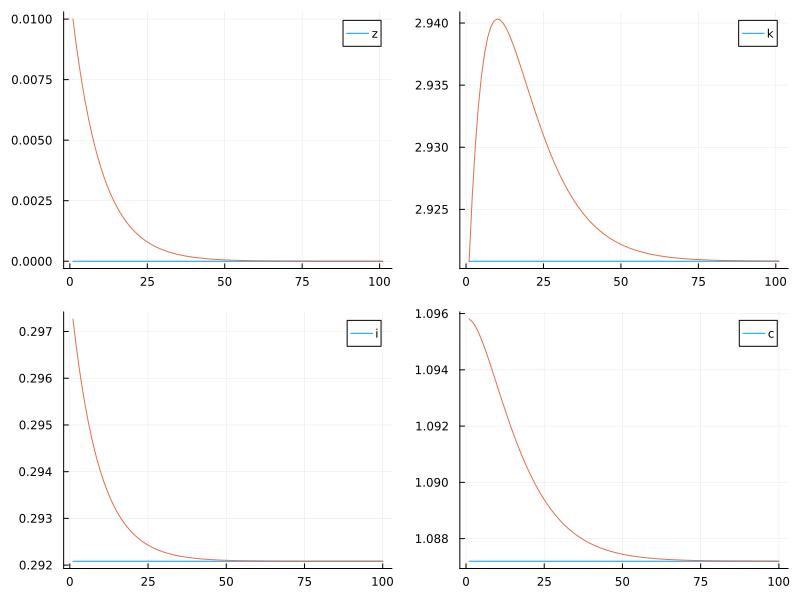

In [75]:
s0, x0= steady_state(model)
s, x = simulate(model, s0, x0, Xbar, 100)
s1 = [0.01, s0[2]] # perturb the model for a small initial shock
s_, x_ = simulate(model, s0, x0, Xbar, 100; s_init = s1)
pl1 = plot(s[:,1], label="z")
pl2 = plot(s[:,2], label="k")
pl3 = plot(x[:,1], label="i")
pl4 = plot(x[:,2], label="c")
plot!(pl1, s_[:,1], label="")
plot!(pl2, s_[:,2], label="")
plot!(pl3, x_[:,1], label="")
plot!(pl4, x_[:,2], label="")
plot(pl1, pl2, pl3, pl4, layout=(2,2), size=(800,600))

Finished in 97 iterations

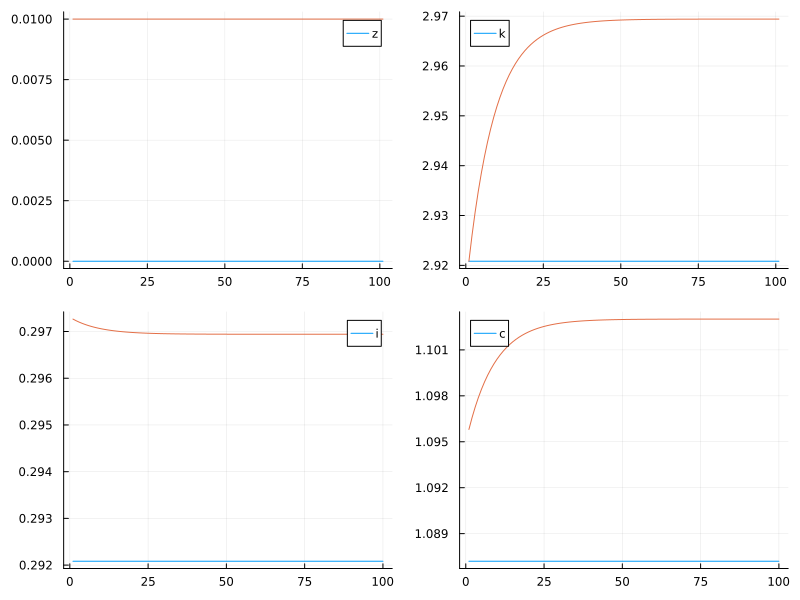

In [79]:
# simulation with unit root

model2 = merge(model, (;ρ=1.0,))

s0, x0= steady_state(model2)
Xbar2 = linear_time_iteration(X0, first_order_model(s0, x0, model2))

s, x = simulate(model2, s0, x0, Xbar, 100)
s1 = [0.01, s0[2]] # perturb the model for a small initial shock
s_, x_ = simulate(model2, s0, x0, Xbar, 100; s_init = s1)
pl1 = plot(s[:,1], label="z")
pl2 = plot(s[:,2], label="k")
pl3 = plot(x[:,1], label="i")
pl4 = plot(x[:,2], label="c")
plot!(pl1, s_[:,1], label="")
plot!(pl2, s_[:,2], label="")
plot!(pl3, x_[:,1], label="")
plot!(pl4, x_[:,2], label="")
plot(pl1, pl2, pl3, pl4, layout=(2,2), size=(800,600))